Common:
1. Data Preparation
2. Explanation Functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.tree import DecisionTreeClassifier, _tree, plot_tree
from scipy.stats import entropy
import math
import warnings

warnings.filterwarnings("ignore")

# 1. Load Data
housing = fetch_california_housing(as_frame=True)
df = housing.frame
target_col = 'MedHouseVal'

# Work with numpy array for speed
y_full = df[target_col].values
N = len(y_full)

print(f"Data loaded. Shape: {df.shape}")

Data loaded. Shape: (20640, 9)


In [2]:
def freedman_diaconis_bins(data):
    """Calculates robust bin edges for histograms."""
    data = np.asarray(data).ravel()
    if data.size < 2: return np.array([data.min(), data.max()])
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25
    if iqr == 0:
        nbins = max(1, int(np.sqrt(data.size)))
    else:
        h = 2 * iqr / (data.size ** (1/3))
        nbins = int(math.ceil((data.max() - data.min()) / h)) if h > 0 else 10
    nbins = max(1, nbins)
    return np.histogram_bin_edges(data, bins=nbins)

def hist_kl(p_samples, q_samples, global_bins, eps=1e-9):
    """Calculates KL(P || Q) using consistent global bins."""
    p, q = np.asarray(p_samples).ravel(), np.asarray(q_samples).ravel()
    p_hist, _ = np.histogram(p, bins=global_bins, density=True)
    q_hist, _ = np.histogram(q, bins=global_bins, density=True)
    p_prob = (p_hist + eps) / (p_hist.sum() + eps * len(p_hist))
    q_prob = (q_hist + eps) / (q_hist.sum() + eps * len(q_hist))
    return float(entropy(p_prob, q_prob))

def jaccard_similarity(mask1, mask2):
    """Calculates IoU to detect duplicate subgroups."""
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0


In [3]:
## RF Utils##
# -------------------------------------------------------------------
# Prune subtrees whose leaves all predict the same class
# -------------------------------------------------------------------
def prune_pure_subtrees(tree: DecisionTreeClassifier) -> None:
    """
    In-place pruning: if all leaves in a subtree predict the same class,
    collapse the whole subtree into a single leaf node without
    changing the tree's predictions.
    """
    tree_ = tree.tree_

    def recurse(node_id: int):
        # Leaf -> return its predicted class index
        if tree_.children_left[node_id] == -1 and tree_.children_right[node_id] == -1:
            value = tree_.value[node_id][0]
            class_index = int(np.argmax(value))
            return {class_index}

        # Recurse into children
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]

        left_classes = recurse(left_id)
        right_classes = recurse(right_id)

        union = left_classes | right_classes

        # If all leaves below predict the same class, prune here
        if len(union) == 1:
            tree_.children_left[node_id] = -1
            tree_.children_right[node_id] = -1
            tree_.feature[node_id] = _tree.TREE_UNDEFINED
            tree_.threshold[node_id] = -2.0
            # Keep tree_.value[node_id] as-is; argmax stays consistent
        return union

    recurse(0)


# -------------------------------------------------------------------
# Count decision questions in a tree
# -------------------------------------------------------------------
def count_questions(tree: DecisionTreeClassifier) -> int:
    tree_ = tree.tree_
    children_left = tree_.children_left
    children_right = tree_.children_right

    # Count only reachable internal nodes (questions) from the root
    def dfs(node_id: int) -> int:
        if node_id == -1:
            return 0
        # leaf
        if children_left[node_id] == -1 and children_right[node_id] == -1:
            return 0
        # internal node
        return 1 + dfs(children_left[node_id]) + dfs(children_right[node_id])

    return int(dfs(0))


# -------------------------------------------------------------------
# YAML export including human-readable questions
# -------------------------------------------------------------------
def tree_to_dict(tree: DecisionTreeClassifier, feature_names):
    """
    Export a sklearn DecisionTreeClassifier into a nested dict for YAML,
    including a readable 'question' field.
    """
    tree_ = tree.tree_
    feature = tree_.feature
    threshold = tree_.threshold

    def recurse(node_id: int):
        # Leaf node
        if tree_.children_left[node_id] == -1 and tree_.children_right[node_id] == -1:
            value = tree_.value[node_id][0]
            class_index = int(np.argmax(value))
            class_label = int(tree.classes_[class_index])
            return {
                'leaf_prediction': class_label,
                'class_counts': value.tolist(),
            }

        # Internal decision node
        feat_name = feature_names[feature[node_id]]
        thresh = float(threshold[node_id])

        return {
            'question': f"{feat_name} <= {thresh}",
            'feature': feat_name,
            'threshold': thresh,
            'left': recurse(tree_.children_left[node_id]),
            'right': recurse(tree_.children_right[node_id]),
        }

    return recurse(0)


# -------------------------------------------------------------------
# Build + evaluate forest (small random forest with constraints)
# -------------------------------------------------------------------
def build_and_evaluate_forest(seed: int):
    """
    Build a small random forest and evaluate on training data.
    For each seed:
      - maximal number of trees ~ Uniform{1,...,10}
      - maximal number of questions per tree ~ Uniform{2,...,10}
    Forest rule: interesting if ANY tree predicts interesting.
    Deterministic for a given seed.
    """
    rng = np.random.RandomState(seed)

    n_samples = X.shape[0]

    # Draw per-seed maxima (deterministic for the seed)
    max_n_trees = rng.randint(1, 11)   # 1..10 inclusive
    max_questions = rng.randint(2, 11) # 2..10 inclusive

    n_trees = max_n_trees

    trees = []
    tree_accuracies = []
    tree_question_counts = []

    print(f"Seed {seed} - max_n_trees={max_n_trees}, max_questions_per_tree={max_questions}")

    for tree_idx in range(n_trees):
        # Bootstrap sample
        bootstrap_indices = rng.choice(n_samples, size=n_samples, replace=True)
        X_boot = X[bootstrap_indices]
        y_boot = y[bootstrap_indices]

        # Each tree has at most max_questions internal decision nodes.
        # Using max_leaf_nodes = max_questions + 1 ensures internal nodes <= max_questions
        tree_random_state = rng.randint(0, 1_000_000)
        clf = DecisionTreeClassifier(
            max_leaf_nodes=max_questions + 1,
            random_state=tree_random_state,
        )
        clf.fit(X_boot, y_boot)

        # Prune subtrees that don't change predictions
        prune_pure_subtrees(clf)

        # Evaluate tree on full training set
        y_pred_tree = clf.predict(X)
        acc_tree = (y_pred_tree == y).mean()

        # Count questions
        n_questions = count_questions(clf)

        print(f"  Tree {tree_idx}: accuracy={acc_tree:.4f}, questions={n_questions}")

        # Store results
        trees.append(clf)
        tree_accuracies.append(acc_tree)
        tree_question_counts.append(n_questions)

        # Save YAML tree
        tree_dict = tree_to_dict(clf, feature_names=feature_cols)
        tree_filename = f"tree_seed{seed}_tree{tree_idx}.yml"
        with open(tree_filename, 'w') as f:
            yaml.dump(tree_dict, f)

    # -------------------------------------------------------------------
    # Forest prediction = OR of all trees' predictions
    # -------------------------------------------------------------------
    all_tree_preds = []
    for clf in trees:
        preds = clf.predict(X)
        all_tree_preds.append(preds.astype(bool))

    pred_matrix = np.vstack(all_tree_preds)
    forest_pred = np.any(pred_matrix, axis=0).astype(int)

    forest_accuracy = (forest_pred == y).mean()
    total_questions = int(np.sum(tree_question_counts))

    print(f"Seed {seed} - Forest accuracy={forest_accuracy:.4f}, "
          f"n_trees={n_trees}, total_questions={total_questions}")
    print("-" * 60)

    return {
        'seed': seed,
        'forest_accuracy': forest_accuracy,
        'n_trees': n_trees,
        'total_questions': total_questions,
    }

In [4]:
# --- added: same pruning helper as in training code ---
def prune_pure_subtrees(tree: DecisionTreeClassifier) -> None:
    """
    In-place pruning: if all leaves in a subtree predict the same class,
    collapse the whole subtree into a single leaf node without
    changing the tree's predictions.
    """
    tree_ = tree.tree_

    def recurse(node_id: int):
        # Leaf -> return its predicted class index
        if tree_.children_left[node_id] == -1 and tree_.children_right[node_id] == -1:
            value = tree_.value[node_id][0]
            class_index = int(np.argmax(value))
            return {class_index}

        # Recurse into children
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]

        left_classes = recurse(left_id)
        right_classes = recurse(right_id)

        union = left_classes | right_classes

        # If all leaves below predict the same class, prune here
        if len(union) == 1:
            tree_.children_left[node_id] = -1
            tree_.children_right[node_id] = -1
            tree_.feature[node_id] = _tree.TREE_UNDEFINED
            tree_.threshold[node_id] = -2.0
            # Keep tree_.value[node_id] as-is; argmax stays consistent
        return union

    recurse(0)
# --- end added helper ---


# 4) Rebuild the forest for this seed (deterministically, same logic as training)
def rebuild_forest_for_seed(seed: int):
    """
    Rebuilds the forest for the given seed using the same logic
    as the training code, and returns the list of trees and the
    per-seed max_questions used.
    """
    rng = np.random.RandomState(seed)
    n_samples = X.shape[0]

    # Same per-seed maxima as in the training cell
    max_n_trees = rng.randint(1, 11)   # 1..10 inclusive
    max_questions = rng.randint(2, 11) # 2..10 inclusive

    n_trees = max_n_trees

    trees = []

    for tree_idx in range(n_trees):
        # Bootstrap sample
        bootstrap_indices = rng.choice(n_samples, size=n_samples, replace=True)
        X_boot = X[bootstrap_indices]
        y_boot = y[bootstrap_indices]

        # Same constraint: at most max_questions internal decision nodes
        tree_random_state = rng.randint(0, 1_000_000)
        clf = DecisionTreeClassifier(
            max_leaf_nodes=max_questions + 1,
            random_state=tree_random_state,
        )
        clf.fit(X_boot, y_boot)
        prune_pure_subtrees(clf)  # <-- added: prune to match training behavior
        trees.append(clf)

    return trees, max_questions


Original Method (from colab)

In [5]:
high_value_quantile = 0.94
# Extract the target as a 1D array reshaped for clustering
X = df[target_col].values.reshape(-1, 1)

# Step 3-5: Perform hierarchical clustering on the target only
method = 'single'
Z = linkage(X, method=method)

# Automatically determine threshold: find the largest jump in merge heights
heights = Z[:, 2]
diffs = np.diff(heights)
if len(diffs) > 0:
    max_diff_idx = np.argmax(diffs)
    threshold = heights[max_diff_idx]  # Cut before the largest gap
else:
    threshold = np.max(heights) if len(heights) > 0 else 0  # Fallback for small data

# Form flat clusters based on the distance threshold
clusters = fcluster(Z, t=threshold, criterion='distance')

# Identify the largest cluster (the "normal" dense group)
unique_clusters, counts = np.unique(clusters, return_counts=True)
largest_cluster_label = unique_clusters[np.argmax(counts)]

# Base: interesting if NOT in largest cluster
interesting_mask = (clusters != largest_cluster_label)

# ---------------------------------------
# NEW: enforce that very large values are interesting
# ---------------------------------------
high_value_cutoff = df[target_col].quantile(high_value_quantile)
interesting_mask |= df[target_col] >= high_value_cutoff

# Step 6: Create new column
df['is_interesting_subgroup'] = interesting_mask

# Step 7: Save the updated DataFrame as a new CSV
df.to_csv('california_housing_with_interesting_og.csv', index=False)

# Optional: Print summary for verification
print(f"Threshold (clustering) used: {threshold}")
print(f"Largest cluster label: {largest_cluster_label}")
print(f"High-value quantile: {high_value_quantile}")
print(f"High-value cutoff: {high_value_cutoff}")
print(f"Number of interesting rows: {df['is_interesting_subgroup'].sum()}")
print("Updated CSV saved as 'california_housing_with_interesting_og.csv'")


Threshold (clustering) used: 0.025009999999999977
Largest cluster label: 1
High-value quantile: 0.94
High-value cutoff: 4.521
Number of interesting rows: 1246
Updated CSV saved as 'california_housing_with_interesting_og.csv'


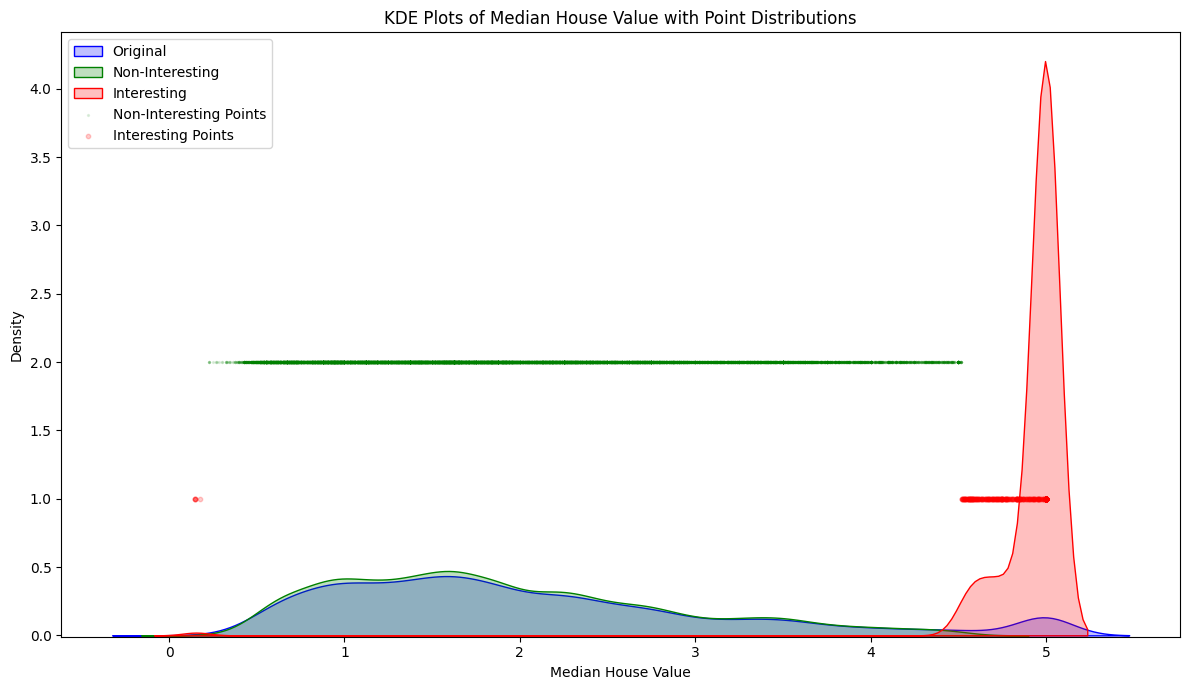

In [6]:
df = pd.read_csv('california_housing_with_interesting_og.csv')

target_col = 'MedHouseVal'

# Subsets
interesting = df[df['is_interesting_subgroup'] == True]
non_interesting = df[df['is_interesting_subgroup'] == False]

plt.figure(figsize=(12, 7))

# KDE plots
sns.kdeplot(df[target_col], color='blue', fill=True, alpha=0.25, label='Original')
sns.kdeplot(non_interesting[target_col], color='green', fill=True, alpha=0.25, label='Non-Interesting')
sns.kdeplot(interesting[target_col], color='red', fill=True, alpha=0.25, label='Interesting')

# ----------------------------------------------------
# SCATTER POINTS ON OFFSET Y-AXES
# ----------------------------------------------------

# Offsets to stack the points visually
y_noninteresting = np.full(len(non_interesting), 2.)   # slight shift below x-axis
y_interesting    = np.full(len(interesting),  1.)       # slight shift above x-axis

# Plot scatter points
plt.scatter(
    non_interesting[target_col],
    y_noninteresting,
    color='green',
    alpha=0.1,
    s=2,
    label='Non-Interesting Points'
)

plt.scatter(
    interesting[target_col],
    y_interesting,
    color='red',
    alpha=0.2,
    s=10,
    label='Interesting Points'
)

# -----------------------------------------
# Formatting
# -----------------------------------------
plt.title("KDE Plots of Median House Value with Point Distributions")
plt.xlabel("Median House Value")
plt.ylabel("Density")

# Hide y values around 0 (scatter offsets)
plt.ylim(-0.01, None)

# Avoid duplicate label entries
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.savefig("house_value_kde_improved.jpg", dpi=300)
plt.show()


In [8]:
#Explanation
import yaml
target_col = 'is_interesting_subgroup'

# EXCLUDE both the target and the original regression target "MedHouseVal"
feature_cols = [c for c in df.columns if c not in [target_col, 'MedHouseVal']]

X = df[feature_cols].values
y = df[target_col].astype(int).values  # binary labels 0/1


# -------------------------------------------------------------------
# Run for 1000 seeds and save results
# -------------------------------------------------------------------
results = []
seeds = list(range(1000))  # 0..99

for s in seeds:
    metrics = build_and_evaluate_forest(s)
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df.to_csv('results_og.csv', index=False)

print("\nSummary of forests:")
print(results_df)




Seed 0 - max_n_trees=6, max_questions_per_tree=2
  Tree 0: accuracy=0.9548, questions=2
  Tree 1: accuracy=0.9540, questions=1
  Tree 2: accuracy=0.9539, questions=1
  Tree 3: accuracy=0.9547, questions=2
  Tree 4: accuracy=0.9533, questions=1
  Tree 5: accuracy=0.9559, questions=2
Seed 0 - Forest accuracy=0.9533, n_trees=6, total_questions=9
------------------------------------------------------------
Seed 1 - max_n_trees=6, max_questions_per_tree=10
  Tree 0: accuracy=0.9608, questions=9
  Tree 1: accuracy=0.9603, questions=7
  Tree 2: accuracy=0.9614, questions=6
  Tree 3: accuracy=0.9612, questions=10
  Tree 4: accuracy=0.9619, questions=10
  Tree 5: accuracy=0.9599, questions=9
Seed 1 - Forest accuracy=0.9568, n_trees=6, total_questions=51
------------------------------------------------------------
Seed 2 - max_n_trees=9, max_questions_per_tree=10
  Tree 0: accuracy=0.9622, questions=10
  Tree 1: accuracy=0.9625, questions=10
  Tree 2: accuracy=0.9610, questions=7
  Tree 3: accur

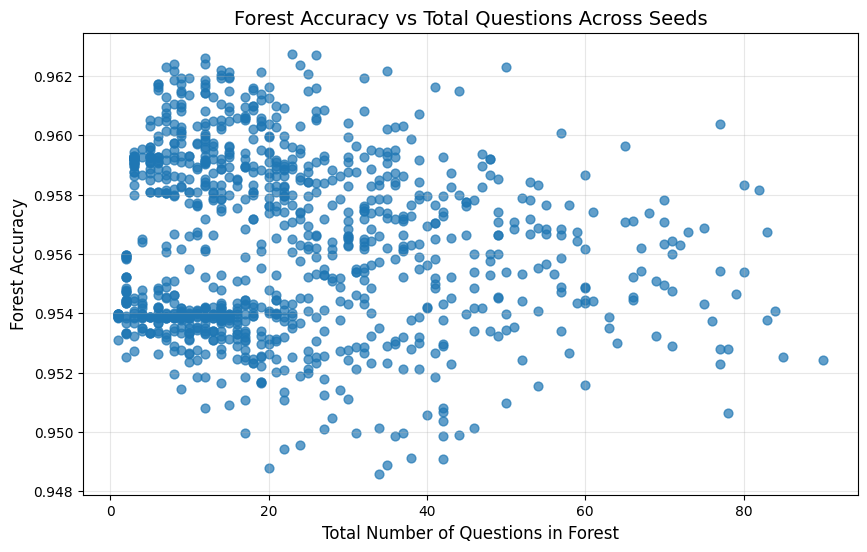

In [9]:
# 1) Read results
results_df = pd.read_csv("results_og.csv")

# 2) Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    results_df["total_questions"],
    results_df["forest_accuracy"],
    s=40,
    alpha=0.7
)

plt.xlabel("Total Number of Questions in Forest", fontsize=12)
plt.ylabel("Forest Accuracy", fontsize=12)
plt.title("Forest Accuracy vs Total Questions Across Seeds", fontsize=14)

plt.grid(True, alpha=0.3)

# Show inline
plt.show()

# 3) Save as JPG
# plt.savefig("accuracy_vs_questions.jpg", dpi=300, bbox_inches="tight")

# print("Saved plot as accuracy_vs_questions.jpg")


Best forest (based on 75% rule and minimal questions):
seed               256.000000
forest_accuracy      0.962306
n_trees              1.000000
total_questions      7.000000
Name: 256, dtype: float64

Rebuilt forest with seed=256
  Number of trees: 1
  Max questions per tree (constraint): 9


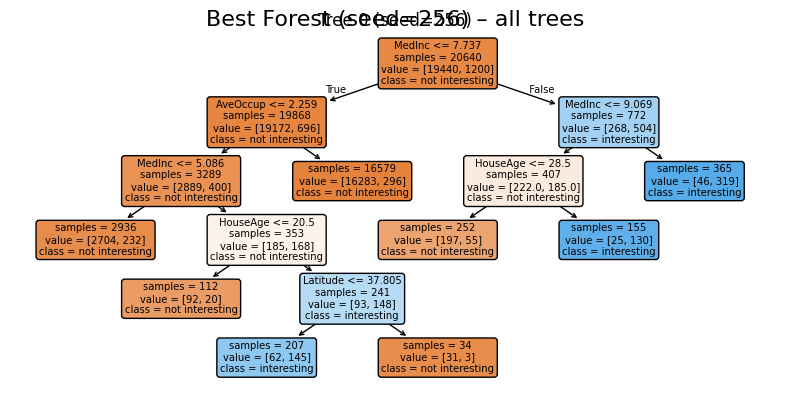

In [10]:
acc_threshold = results_df["forest_accuracy"].quantile(0.99)

# Forests strictly better than 75% of all
top_df = results_df[results_df["forest_accuracy"] > acc_threshold]

# Fallback: if none strictly greater, allow >=
if top_df.empty:
    top_df = results_df[results_df["forest_accuracy"] >= acc_threshold]

# 3) Among these, choose the one with:
#    - smallest total_questions
#    - if tie: highest forest_accuracy
#    - if tie again: smallest seed
top_sorted = top_df.sort_values(
    by=["total_questions", "forest_accuracy", "seed"],
    ascending=[True, False, True]
)

best_row = top_sorted.iloc[0]
best_seed = int(best_row["seed"])

print("Best forest (based on 75% rule and minimal questions):")
print(best_row)
trees, max_questions = rebuild_forest_for_seed(best_seed)
n_trees = len(trees)

print(f"\nRebuilt forest with seed={best_seed}")
print(f"  Number of trees: {n_trees}")
print(f"  Max questions per tree (constraint): {max_questions}")


# 5) Visualize the entire forest (all trees) in one figure
if n_trees == 1:
    n_cols = 1
else:
    n_cols = 2  # up to 2 trees per row for readability
n_rows = int(np.ceil(n_trees / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 4 * n_rows))

# Make axes iterable in a flat array
if n_trees == 1:
    axes = np.array([axes])
else:
    axes = np.array(axes).reshape(-1)

for idx, (clf, ax) in enumerate(zip(trees, axes)):
    plot_tree(
        clf,
        feature_names=feature_cols,
        class_names=["not interesting", "interesting"],
        filled=True,
        rounded=True,
        impurity=False,
        ax=ax
    )
    ax.set_title(f"Tree {idx} (seed={best_seed})")

# Hide any unused axes (if n_trees is odd)
for ax in axes[n_trees:]:
    ax.axis("off")

fig.suptitle(f"Best Forest (seed={best_seed}) – all trees", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save as JPG
# plt.savefig("best_forest_all_trees.jpg", dpi=300, bbox_inches="tight")

# Show inline
plt.show()

# print("Saved forest visualization as best_forest_all_trees.jpg")


New Method - Clustering + Syflow

In [ ]:
n_seeds = 1000          # High number for robust discovery
beta = 0.5              # Size adjustment factor
lambd_div = 2.0         # Diversity weight
top_percentile = 0.01   # Select Top 1% (0.01) or Top 0.5% (0.005)
max_overlap = 0.95       # Discard candidates with >80% overlap with existing selections

# Pre-calculate global bins once
global_bins = freedman_diaconis_bins(y_full)

# --- C) Candidate Generation ---
print(f"Generating candidates over {n_seeds} seeds...")
candidates = []

for seed in range(n_seeds):
    if seed % 100 == 0: print(f"  Processed {seed} seeds...")
    
    # 1. Bootstrap
    np.random.seed(seed)
    sample_idx = np.random.choice(N, size=N, replace=True)
    y_boot = y_full[sample_idx].reshape(-1, 1)
    
    # 2. Clustering (Single Linkage for Speed/Outliers)
    # try:
    Z = linkage(y_boot, method='single')
    # except Exception:
        # continue
        
    # Thresholding (Max Jump)
    heights = Z[:, 2]
    diffs = np.diff(heights)
    threshold = heights[np.argmax(diffs)] if len(diffs) > 0 else 0.0
    if threshold == 0: continue

    # 3. Extract Clusters
    boot_clusters = fcluster(Z, t=threshold, criterion='distance')
    unique_labels = np.unique(boot_clusters)
    
    # 4. Evaluate Each Cluster
    for label in unique_labels:
        # Get range from bootstrap
        cluster_vals = y_boot[boot_clusters == label]
        if len(cluster_vals) == 0: continue
        c_min, c_max = cluster_vals.min(), cluster_vals.max()
        
        # Apply to Full Data
        mask = (y_full >= c_min) & (y_full <= c_max)
        n_sub = mask.sum()
        
        # Filter trivial (too small or too large)
        if n_sub < 50 or n_sub > (N * 0.90): continue
        
        # Syflow Scoring (Size^beta * KL)
        sub_y = y_full[mask]
        kl_exc = hist_kl(sub_y, y_full, global_bins)
        size_term = (n_sub / N) ** beta
        quality = size_term * kl_exc
        
        candidates.append({
            'seed': seed,
            'mask': mask,
            'y_values': sub_y,
            'size_term': size_term,
            'quality': quality,
            'range': (c_min, c_max),
            'selected': False
        })

print(f"Generated {len(candidates)} candidates.")

# --- D) Iterative Selection (Percentile-Based Count) ---
# Determine how many to select based on the requested percentile
n_select = int(len(candidates) * top_percentile)
n_select = max(1, n_select) # Ensure at least 1 is selected

print(f"Selecting Top {top_percentile*100}% Subgroups -> Target Count: {n_select}")

selected_candidates = []

for k in range(n_select):
    best_candidate = None
    best_score = -np.inf
    
    for cand in candidates:
        if cand['selected']: continue
        
        # 1. Dedup: Skip if too similar to ANY already selected
        is_duplicate = False
        for sel in selected_candidates:
            if jaccard_similarity(cand['mask'], sel['mask']) > max_overlap:
                is_duplicate = True
                break
        if is_duplicate:
            cand['selected'] = True # Mark as processed/skipped
            continue

        # 2. Diversity Term: Average KL to selected
        diversity = 0.0
        if len(selected_candidates) > 0:
            for sel in selected_candidates:
                diversity += hist_kl(cand['y_values'], sel['y_values'], global_bins)
            diversity /= len(selected_candidates)
        
        # 3. Final Syflow Objective
        total_score = cand['quality'] + (lambd_div * cand['size_term'] * diversity)
        
        if total_score > best_score:
            best_score = total_score
            best_candidate = cand
            
    if best_candidate is None: 
        print("No more distinct candidates found.")
        break
        
    best_candidate['selected'] = True
    selected_candidates.append(best_candidate)
    
    div_contrib = best_score - best_candidate['quality']
    print(f"  Selected #{k+1}: Range [{best_candidate['range'][0]:.2f}, {best_candidate['range'][1]:.2f}] | "
          f"Score={best_score:.4f} (Qual={best_candidate['quality']:.4f}, Div={div_contrib:.4f})")

# --- E) Final Union ---
final_mask = np.zeros(N, dtype=bool)
for cand in selected_candidates:
    final_mask |= cand['mask']

df['is_interesting_subgroup'] = final_mask
df.to_csv('california_housing_with_interesting.csv', index=False)
print(f"Total Interesting Rows: {final_mask.sum()}")

Generating candidates over 1000 seeds...
  Processed 0 seeds...
  Processed 100 seeds...
  Processed 200 seeds...
  Processed 300 seeds...
  Processed 400 seeds...
  Processed 500 seeds...
  Processed 600 seeds...
  Processed 700 seeds...


In [ ]:
# ---------------------------------------------------------
# Step 3: Visualization (KDE + Scatter)
# ---------------------------------------------------------
target_col = 'MedHouseVal'

interesting = df[df['is_interesting_subgroup'] == True]
non_interesting = df[df['is_interesting_subgroup'] == False]

plt.figure(figsize=(12, 7))

# KDE plots
sns.kdeplot(df[target_col], color='blue', fill=True, alpha=0.25, label='Original')
sns.kdeplot(non_interesting[target_col], color='green', fill=True, alpha=0.25, label='Non-Interesting')
sns.kdeplot(interesting[target_col], color='red', fill=True, alpha=0.25, label='Interesting')

# Scatter points on offset y-axes
y_noninteresting = np.full(len(non_interesting), 2.)   # slight shift
y_interesting    = np.full(len(interesting),  1.)      # slight shift

plt.scatter(
    non_interesting[target_col],
    y_noninteresting,
    color='green',
    alpha=0.1,
    s=2,
    label='Non-Interesting Points'
)

plt.scatter(
    interesting[target_col],
    y_interesting,
    color='red',
    alpha=0.2,
    s=10,
    label='Interesting Points'
)

plt.title("KDE Plots of Median House Value with Point Distributions (Syflow Discovery)")
plt.xlabel("Median House Value")
plt.ylabel("Density")
plt.ylim(-0.01, None)

handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------------------
# Run for 1000 seeds and save results
# -------------------------------------------------------------------
results = []
seeds = list(range(1000))  # 0..99

for s in seeds:
    metrics = build_and_evaluate_forest(s)
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df.to_csv('results.csv', index=False)

print("\nSummary of forests:")
print(results_df)
acc_threshold = results_df["forest_accuracy"].quantile(0.99)

# Forests strictly better than 75% of all
top_df = results_df[results_df["forest_accuracy"] > acc_threshold]

# Fallback: if none strictly greater, allow >=
if top_df.empty:
    top_df = results_df[results_df["forest_accuracy"] >= acc_threshold]

# 3) Among these, choose the one with:
#    - smallest total_questions
#    - if tie: highest forest_accuracy
#    - if tie again: smallest seed
top_sorted = top_df.sort_values(
    by=["total_questions", "forest_accuracy", "seed"],
    ascending=[True, False, True]
)

best_row = top_sorted.iloc[0]
best_seed = int(best_row["seed"])

print("Best forest (based on 75% rule and minimal questions):")
print(best_row)

trees, max_questions = rebuild_forest_for_seed(best_seed)
n_trees = len(trees)

print(f"\nRebuilt forest with seed={best_seed}")
print(f"  Number of trees: {n_trees}")
print(f"  Max questions per tree (constraint): {max_questions}")


# 5) Visualize the entire forest (all trees) in one figure
if n_trees == 1:
    n_cols = 1
else:
    n_cols = 2  # up to 2 trees per row for readability
n_rows = int(np.ceil(n_trees / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 4 * n_rows))

# Make axes iterable in a flat array
if n_trees == 1:
    axes = np.array([axes])
else:
    axes = np.array(axes).reshape(-1)

for idx, (clf, ax) in enumerate(zip(trees, axes)):
    plot_tree(
        clf,
        feature_names=feature_cols,
        class_names=["not interesting", "interesting"],
        filled=True,
        rounded=True,
        impurity=False,
        ax=ax
    )
    ax.set_title(f"Tree {idx} (seed={best_seed})")

# Hide any unused axes (if n_trees is odd)
for ax in axes[n_trees:]:
    ax.axis("off")

fig.suptitle(f"Best Forest (seed={best_seed}) – all trees", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save as JPG
# plt.savefig("best_forest_all_trees.jpg", dpi=300, bbox_inches="tight")

# Show inline
plt.show()

# print("Saved forest visualization as best_forest_all_trees.jpg")
